this code simulates a LED diode as source,
light diffract at primary lens at 220μm from diode, (through LED medium of epoxy)
then diffract at a secondary lens (through glass medium)

In [1]:
config_path = "results/LED_collimator1220_pinhole/config.yaml"
import numpy as np; import matplotlib.pyplot as plt # type: ignore
from datetime import datetime
import src.RS as RS
import src.math_tool as mt
import src.img_tool as it
import src.load_config as lc
import src.utils as utils
from tqdm import tqdm
import src.ASM as ASM
import gc
%matplotlib widget
%load_ext autoreload
%autoreload 2
c, π = lc.load(config_path), np.pi
Axs2D, Ays2D = np.meshgrid(c.sim.xs, c.sim.ys, indexing='ij')
Nθs = 64
θ0s = np.linspace(0, 2*π, Nθs, endpoint=False, dtype=np.float32)
n_L = 1.5 # refractive index in LED casing (epoxy)
n_G = 1.5 # refractive index in glass
edge_pinhole = it.block_edge_mask(c.sim.Nx, c.sim.Ny, c.sim.Nx//300*45)
edge = it.block_edge_mask(c.sim.Nx, c.sim.Ny, c.sim.Nx//2) # Nx, Ny # circle mask of Nx x Ny pixel with pixel radius

cannot load aperture file


1. Design of collimator lens

1.1 simulate light from diode to LED surface

In [ ]:
# Axy = np.zeros_like(Axs2D, dtype=complex)
# # config the Aperture plane

# #simulate wave from a point on LED diode propagate to pinhole, in medium of refractive index n_L (probably epoxy)
# x_L_point = np.array([0])
# y_L_point = np.array([0])
# z_L_point = np.array([-220]) # N_point # location of electron hole recombination
# θ_L_point = np.array([0])
# magnitude_L_point = np.array([1])
# # Rayleigh Sommerfeld summation
# λ = c.λ/n_L
# k = c.k * n_L
# r = mt.dist(Axs2D[:, :, None], Ays2D[:, :, None], z=0, x_c = x_L_point, y_c=y_L_point, z_c = z_L_point) # Nx, Ny, N_point
# E_center_0 = (-1j/λ * np.exp(k*1j*r)*z_L_point/r**2)@(np.exp(1j*θ_L_point)*magnitude_L_point) # Nx, Ny

1.2 simulate through pinhole of 45μm at LED surface

In [ ]:
# # adding pinhole at z=0, and radius 45μm (20 + (150-20)/1220*220 ~=43.4426)
# E_center_0 *= edge_pinhole

1.3 simulate light from pinhole to 1000μm (glass surface, location of collimator)

In [ ]:
# aperture = E_center_0
# pad_value = 900
# mul = 2*pad_value//len(aperture)+1
# ASM.ASM_3D_batch_E_Multi_Process(A_xy=it.img_pad(aperture, (pad_value,pad_value,pad_value,pad_value), pad_val=0), Lx = c.sim.Lx*mul, Ly=c.sim.Ly*mul, zs=c.sim.zs,\
#                                   λ=c.λ/n_G, path=c.path.E,\
#                                   batch_size=4, xy_range_idx=(pad_value, -pad_value, pad_value, -pad_value), num_process=6)
# time = datetime.now()
# print(f'last run: {time.isoformat(timespec="minutes")}')

In [ ]:
# # extract results
# E_center_0_2000_20 = ASM.batch_E_extract(c.sim.Nx, c.sim.Ny, len(c.sim.zs), c.path.E, batch_size=4)
# time = datetime.now()
# print(f'last run: {time.isoformat(timespec="minutes")}')
# E_center_1000 = E_center_0_2000_20[:, :, 10]

1.4 fit E-field at 1000μm to the lens

In [ ]:
# E_center_target_1000 = 1 # plane wave
# E_relative_1000 = E_center_1000 / E_center_target_1000
# θ_aperture = np.angle(E_relative_1000)
# cos_θ_aperture_θ0s = np.cos(θ_aperture[..., None]-θ0s) # Nx, Ny, Nθs
# # print(cos_θ_aperture_θ0s.shape)
# # apply constraint of 100μm diameter
# aperture_design = (cos_θ_aperture_θ0s > 0) * ( edge[:, :, None] == True ) # set edge to block
# # find best possible match over range of reference phase
# #                  phase_similarity (Nx, Ny, Nθs)
# cosine_similarity = (cos_θ_aperture_θ0s * aperture_design * np.abs(E_center_1000)[:, :, None]).sum(axis=(0, 1)) # Nθs (range of reference phase)
# idx_max = cosine_similarity.argmax()
# idx_min = cosine_similarity.argmin()
# print(f'min similarity phase / max similarity phase\n{cosine_similarity[idx_min] / cosine_similarity[idx_max]}')
# import gc
# del cos_θ_aperture_θ0s
# lens = aperture_design[:, :, idx_max]
# del aperture_design
# gc.collect()

In [ ]:
# plt.imshow(lens.T);plt.gca().invert_yaxis()
# plt.xticks(c.x_tick_idxs, c.xs[c.x_tick_idxs])
# plt.yticks(c.y_tick_idxs, c.ys[c.y_tick_idxs])
# plt.show()
# name = 'LED_-1220μm_2_ooμm_λ620nm_300_pinhole'
# it.array_2_img(lens, f'{c.path.results}/{name}.bmp')

1.5 Discover the lens is the same as in LED_collimator1220 case, but with around 3% noise

In [25]:
# they looks the same, but this verions have less noise
lens2 = it.img_2_array('results/LED_collimator1220/LED_-1220μm_2_ooμm_λ620nm_300_zoom2.bmp')
lens = lens2

2. Simulation of light from a point on LED diode to lens (E_test)

2.1 Simulation of test light from LED diode to pinhole

In [26]:
x_L_point = np.array([40])
y_L_point = np.array([0])
z_L_point = np.array([-220]) # N_point # location of electron hole recombination
θ_L_point = np.array([0])
magnitude_L_point = np.array([1])
# Rayleigh Sommerfeld summation
n_L = 1.5
λ = c.λ/n_L
k = c.k * n_L
r = mt.dist(Axs2D[:, :, None], Ays2D[:, :, None], z=0, x_c = x_L_point, y_c=y_L_point, z_c = z_L_point) # Nx, Ny, N_point
E_test_0 = ((-1j/λ * np.exp(k*1j*r)*z_L_point/r**2)@(np.exp(1j*θ_L_point)*magnitude_L_point)) * c.Δx * c.Δy# Nx, Ny
E_test_0 *= edge_pinhole # set edge to block

2.2 Simulation of test light form pinhole to lens

In [27]:
aperture = E_test_0
pad_value = 900
mul = 2*pad_value//len(aperture)+1
ASM.ASM_3D_batch_E_Multi_Process(A_xy=it.img_pad(aperture, (pad_value,pad_value,pad_value,pad_value), pad_val=0), Lx = c.sim.Lx*mul, Ly=c.sim.Ly*mul, zs=c.sim.zs,\
                                  λ=c.λ/n_G, path=c.path.E,\
                                  batch_size=4, xy_range_idx=(pad_value, -pad_value, pad_value, -pad_value), num_process=6)
time = datetime.now()
print(f'last run: {time.isoformat(timespec="minutes")}')

ASM simulation: 0it [00:00, ?it/s]/1 [00:00<?, ?it/s]
ASM simulation: 0it [00:00, ?it/s]
ASM simulation: 0it [00:00, ?it/s]
ASM simulation: 0it [00:00, ?it/s]
ASM simulation: 0it [00:00, ?it/s]
ASM simulation: 100%|██████████| 1/1 [00:02<00:00,  2.05s/it]


last run: 2025-12-03T11:26


In [28]:
# extract results
E_test_0_2000_20 = ASM.batch_E_extract(c.sim.Nx, c.sim.Ny, len(c.sim.zs), c.path.E, batch_size=4)
time = datetime.now()
print(f'last run: {time.isoformat(timespec="minutes")}')
E_test_1000 = E_test_0_2000_20[:, :, 1]
E_test_1000_lens = E_test_1000 * lens
E_test_1000 *= edge

extracting: 100%|██████████| 1/1 [00:00<00:00, 17.49it/s]

last run: 2025-12-03T11:26


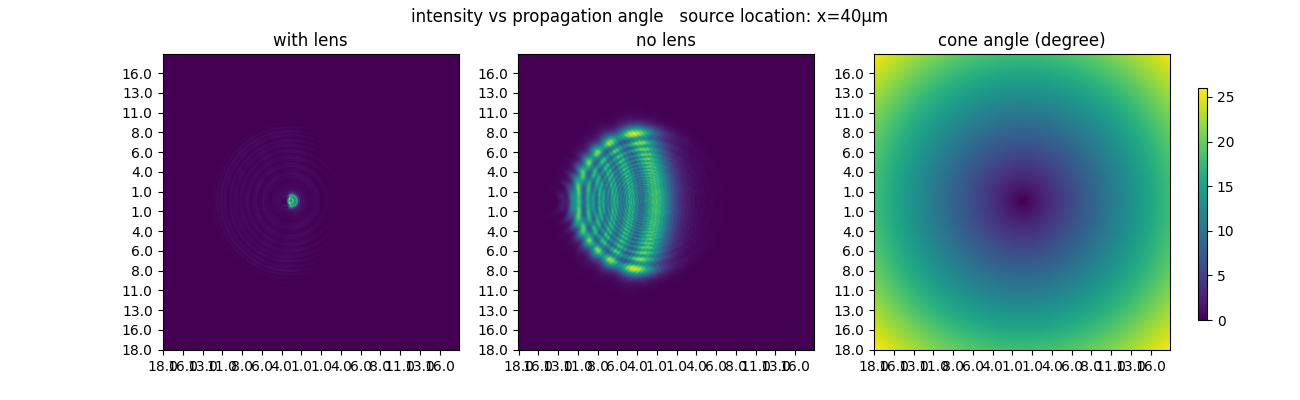

In [15]:
plt.imshow(E_test_1000.real)
plt.show()

3. find intensity distribution vs angle (E_test_0)
vs 
intensity distribution vs angle after lens (E_test_0_lens)

(600, 600)


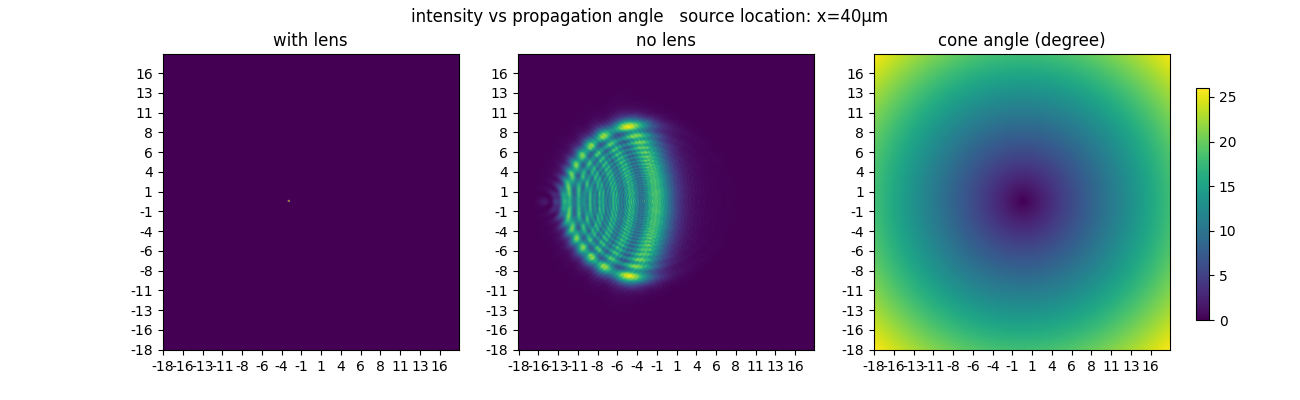

In [ ]:
intensity_dist_lens, kθ, xθ, yθ = ASM.Angular_intensity_dist(E_test_1000_lens, c.sim.Lx, c.sim.Ly, λ=c.λ)
intensity_dist, _, _, _ = ASM.Angular_intensity_dist(E_test_1000, c.sim.Lx, c.sim.Ly, λ=c.λ)
print(intensity_dist.shape)
f_range = 150; Nx, Ny = intensity_dist_lens.shape
plt.clf()
layout = [[0, 1, 2]]
fig, ax = plt.subplot_mosaic(layout, figsize=(13,4))
# plots = [np.fft.fftshift(intensity_dist_lens), np.fft.fftshift(intensity_dist_lens)[Nx // 2 - f_range: Nx // 2 + f_range, Nx // 2 - f_range: Nx // 2 + f_range], np.fft.fftshift(kθ.real)[Nx // 2 - f_range: Nx // 2 + f_range, Nx // 2 - f_range: Nx // 2 + f_range]]
plots = [np.fft.fftshift(intensity_dist_lens)[Nx // 2 - f_range: Nx // 2 + f_range, Ny // 2 - f_range: Ny // 2 + f_range], np.fft.fftshift(intensity_dist)[Nx // 2 - f_range: Nx // 2 + f_range, Nx // 2 - f_range: Nx // 2 + f_range], np.fft.fftshift(kθ.real)[Nx // 2 - f_range: Nx // 2 + f_range, Nx // 2 - f_range: Nx // 2 + f_range]]
title = ['with lens', 'no lens','cone angle (degree)']
x_angles = np.fft.fftshift(xθ)[Nx // 2 - f_range: Nx // 2 + f_range, Nx // 2 - f_range: Nx // 2 + f_range]
y_angles = np.fft.fftshift(yθ)[Ny // 2 - f_range: Ny // 2 + f_range, Ny // 2 - f_range: Ny // 2 + f_range]
x_angle_ticks = np.linspace(0, len(x_angles), len(x_angles)//20, endpoint=False, dtype=int)
y_angle_ticks = np.linspace(0, len(y_angles), len(y_angles)//20, endpoint=False, dtype=int)
im = []

fig.suptitle("intensity vs propagation angle   source location: x=40μm")
for i in range(len(plots)):
    im.append(ax[i].imshow(plots[i].T));ax[i].invert_yaxis()
    ax[i].set_title(title[i])
    ax[i].set_xticks(x_angle_ticks, np.round(x_angles[x_angle_ticks, 0].real).astype(int))
    ax[i].set_yticks(y_angle_ticks, np.round(y_angles[0, y_angle_ticks].real).astype(int))

cax = fig.add_axes([0.92, 0.2, 0.01, 0.58])
fig.colorbar(im[2], cax=cax)
plt.show()
plt.savefig(f'{c.path.results}/angular_intensity_spectrum.png', dpi=300)

In [ ]:
plt.clf()
cone_angle = np.linspace(0, 25, 25, endpoint=False)

total_intensity = intensity_dist.sum()

select_cone = (cone_angle < (kθ.real)[:, :, None]) * ((kθ.real)[:, :, None] < np.roll(cone_angle, -1)) # Nx, Ny, N_angle
#select_cone = ((kθ.real)[:, :, None] < cone_angle) # Nx, Ny, N_angle
cone_intensity = (intensity_dist[:, :, None] * select_cone ).sum(axis=(0,1))

total_intensity_lens = intensity_dist_lens.sum()
cone_intensity_lens = (intensity_dist_lens[:, :, None] * select_cone).sum(axis=(0,1))
plt.plot(cone_angle, cone_intensity / total_intensity*100, label=f'no lens --total intensity {total_intensity}')
plt.plot(cone_angle, cone_intensity_lens / total_intensity_lens*100, label=f'with lens --total intensity {total_intensity_lens}')
plt.legend()
print(f'number of sample point: {((kθ.real)[:, :, None] < cone_angle).sum(axis=(0,1))}')
plt.title('% of intensity within forward cone\nvs cone angle (degree)')
plt.show()